# 01 Test Enviroment

This notebook is to serve as a test ground for building an numerical shortest path optimiser

In [11]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd

print("Environment working!")

Environment working!


Initially, I want to test my optimisation methods on a uniform cost field with uniform costs and no terrain features. The terrain is a over a domain of 
$$
\Omega = [0,\text{width}] \times [0,\text{height}]
$$

The cost is a function 
$$
c : \Omega \rightarrow [0,1]
$$

In this simple version the $c = 0.1$ uniformly. In futrure cost value will vary bassed on terain features


In [12]:
import sys

sys.path.append("../src")

from terrain.terrain import Terrain

In [ ]:
terrain = Terrain(
    width=100,
    height=100,
    resolution=100,
    cost=0.1
)

terrain.grid.shape
terrain_df = pd.DataFrame(terrain.grid)

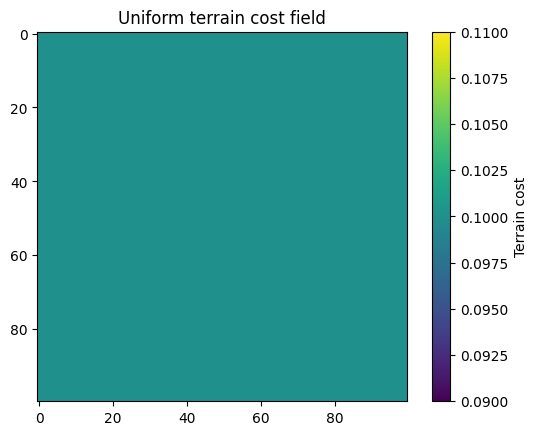

In [14]:
plt.imshow(terrain_df)

plt.colorbar(label="Terrain cost")

plt.title("Uniform terrain cost field")

plt.show()

Next I want to add end points for my curve. These points are analogous to train stations or towns.

In [30]:
from geometry.endpoints import Endpoints

boundary = Endpoints(
    start=(10, 20),
    end=(80, 80)
)

boundary.start
boundary.end

(80, 80)

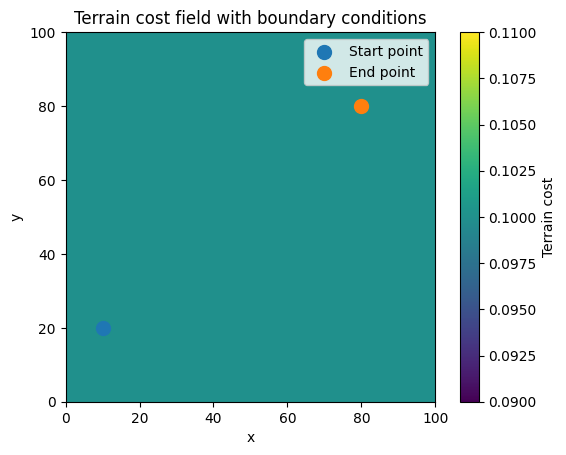

In [22]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.colorbar(label="Terrain cost")

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

I want to optimise the cost of this path. we should get shortest path more distance increases cost. the functional becomes
$$
J(\gamma) = \int_\gamma c(x,y) \, ds
$$
next we discretise the points along the path. so get 
$$
J(\gamma_h) = \sum_{i=0}^{N-1} c(p_i)|p_{i+1} - p_i|
$$

I have a straight_line_path function to create a straight line though the two points. no optimisation just yet. just an initial solution

In [24]:
from geometry.path import Path

In [37]:
from geometry.generators import straight_line_path


path = straight_line_path(
    start=(boundary.start[0],boundary.start[1]),
    end=(boundary.end[0],boundary.end[1]),
    num_points=100
)

In [38]:
path.points

array([[10.        , 20.        ],
       [10.70707071, 20.60606061],
       [11.41414141, 21.21212121],
       [12.12121212, 21.81818182],
       [12.82828283, 22.42424242],
       [13.53535354, 23.03030303],
       [14.24242424, 23.63636364],
       [14.94949495, 24.24242424],
       [15.65656566, 24.84848485],
       [16.36363636, 25.45454545],
       [17.07070707, 26.06060606],
       [17.77777778, 26.66666667],
       [18.48484848, 27.27272727],
       [19.19191919, 27.87878788],
       [19.8989899 , 28.48484848],
       [20.60606061, 29.09090909],
       [21.31313131, 29.6969697 ],
       [22.02020202, 30.3030303 ],
       [22.72727273, 30.90909091],
       [23.43434343, 31.51515152],
       [24.14141414, 32.12121212],
       [24.84848485, 32.72727273],
       [25.55555556, 33.33333333],
       [26.26262626, 33.93939394],
       [26.96969697, 34.54545455],
       [27.67676768, 35.15151515],
       [28.38383838, 35.75757576],
       [29.09090909, 36.36363636],
       [29.7979798 ,

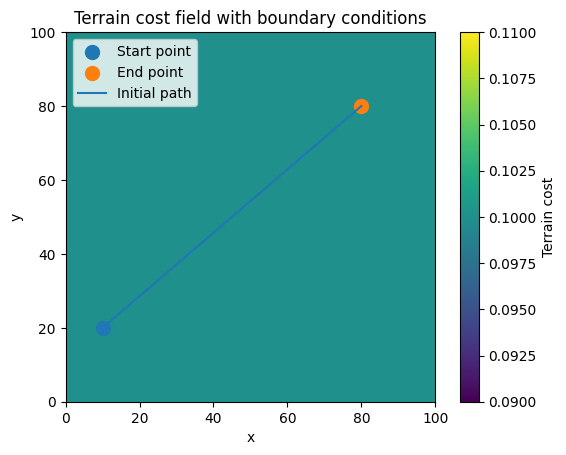

In [39]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.colorbar(label="Terrain cost")

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot(
    path.points[:,0],
    path.points[:,1],
    label="Initial path"

)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

we can now check the cost of this path. here i will check that the terrain_cost function works 

In [43]:
from cost_functions.terrain_cost import terrain_cost

cost = terrain_cost(
    path,
    terrain
)

print(cost)

9.219544457292882


since we know that the straight line is optimal, we can check this mathematically using pythagoras thoerem

In [42]:
path.length()*terrain.cost

np.float64(9.219544457292889)

lets check against a bath path

In [44]:
from geometry.path import Path

bad_path = Path([
    (10, 20),
    (30, 20),
    (30, 90),
    (70, 90),
    (70, 40),
    (80, 80)
])

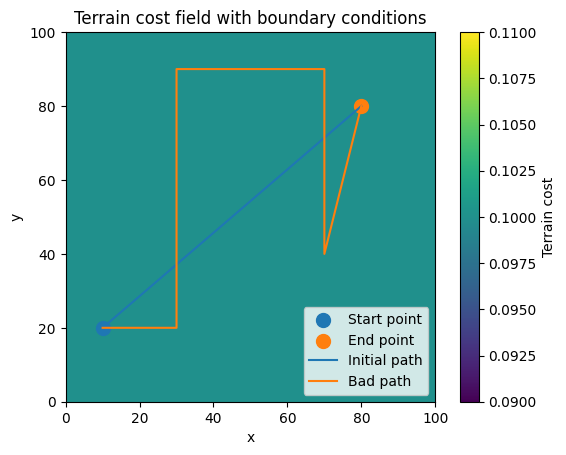

In [46]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.colorbar(label="Terrain cost")

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot(
    path.points[:,0],
    path.points[:,1],
    label="Initial path"

)

plt.plot(
    bad_path.points[:,0],
    bad_path.points[:,1],
    label="Bad path"

)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [45]:
print("Straight length:", path.length())
print("Bad length:", bad_path.length())


print("Straight cost:", terrain_cost(path, terrain))
print("Bad cost:", terrain_cost(bad_path, terrain))

Straight length: 92.19544457292888
Bad length: 221.2310562561766
Straight cost: 9.219544457292882
Bad cost: 22.12310562561766


from this we can see we have created a reasonable simulation